# Pairs Trading Across Sector ETFs: Mean Reversion from Weighting & Flow Frictions

**MGMTMFE-413 Statistical Arbitrage Research Project**

## Project Overview

This notebook implements a comprehensive pairs trading strategy on same-sector ETF pairs that:
- Uses time-varying hedge ratios via Kalman filtering
- Models spread mean reversion as an OU/AR(1) process
- Conditions signals on flow differentials and holdings overlap
- Implements robust backtesting with purged & embargoed walk-forward validation
- Includes robustness checks (SPA test, structural breaks, event studies)

## Table of Contents

1. [Setup and Configuration](#setup)
2. [Data Loading and Preprocessing](#data)
3. [Hedge Ratio Estimation (Kalman Filter)](#kalman)
4. [Mean Reversion Analysis](#meanrev)
5. [Signal Generation](#signals)
6. [Backtesting](#backtest)
7. [Performance Evaluation](#performance)
8. [Robustness Checks](#robustness)
9. [Results and Interpretation](#results)



## 1. Setup and Configuration {#setup}


In [5]:
import sys
from pathlib import Path

# Add src to path
project_root = Path.cwd()
sys.path.insert(0, str(project_root / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import project modules
import config
from data_loader import ETFDataLoader
from wrds_loader import WRDSETFLoader, load_etf_pairs_from_wrds
from kalman_filter import KalmanFilter, estimate_hedge_ratio_kalman
from mean_reversion import estimate_ar1, rolling_ar1, adf_test, compute_mean_reversion_metrics
from signal_generation import generate_signals, compute_position_sizes, compute_zscore
from backtesting import WalkForwardBacktest, run_backtest
from performance import compute_performance_metrics, compute_rolling_metrics
from robustness import (
    spa_test, detect_structural_breaks, event_study,
    identify_large_flow_events, compute_robustness_checks
)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("✓ Imports successful")
print(f"Project root: {project_root}")
print(f"ETF Pairs: {config.ETF_PAIRS}")


✓ Imports successful
Project root: /Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project
ETF Pairs: [('XLE', 'VDE', 'Energy'), ('XLK', 'FTEC', 'Technology'), ('XLF', 'VFH', 'Financials'), ('XLI', 'VIS', 'Industrials'), ('XLV', 'VHT', 'Healthcare')]


## 2. Data Loading and Preprocessing {#data}

**Note:** This section assumes you have data files or will connect to WRDS/Refinitiv.
For demonstration, we'll show the structure and provide placeholder code.


In [6]:
# Load all ETF pairs from WRDS
from wrds_loader import WRDSETFLoader

# Initialize WRDS loader
wrds_username = 'chalakorn'
loader = WRDSETFLoader(wrds_username=wrds_username, data_dir='data/raw')

print("="*70)
print("Loading All ETF Pairs from WRDS")
print("="*70)
print(f"Date range: {config.START_DATE} to {config.END_DATE}")
print(f"Total pairs to load: {len(config.ETF_PAIRS)}\n")

# Get all unique symbols first
all_symbols = set()
for symbol_a, symbol_b, sector in config.ETF_PAIRS:
    all_symbols.add(symbol_a)
    all_symbols.add(symbol_b)

print(f"Step 1: Loading {len(all_symbols)} unique ETFs...")
print("-"*70)

# Load all unique ETFs first
loaded_symbols = {}
for symbol in sorted(all_symbols):
    print(f"  Loading {symbol}...", end=" ")
    try:
        data = loader.load_etf_price_data_wrds(
            symbol,
            start_date=config.START_DATE,
            end_date=config.END_DATE
        )
        if not data.empty:
            loaded_symbols[symbol] = data
            date_range = f"{data.index.min().strftime('%Y-%m-%d')} to {data.index.max().strftime('%Y-%m-%d')}"
            print(f"✓ {len(data)} days ({date_range})")
        else:
            print(f"✗ No data returned")
    except Exception as e:
        print(f"✗ Error: {str(e)[:100]}")

print(f"\n✓ Successfully loaded {len(loaded_symbols)}/{len(all_symbols)} ETFs")

# Step 2: Create pair datasets
print(f"\nStep 2: Creating {len(config.ETF_PAIRS)} pair datasets...")
print("-"*70)

pair_datasets = {}
pair_summary = []

for symbol_a, symbol_b, sector in config.ETF_PAIRS:
    print(f"\n  Pair: {symbol_a} - {symbol_b} ({sector})")
    
    # Check if both ETFs are loaded
    if symbol_a not in loaded_symbols:
        print(f"    ✗ {symbol_a} not loaded - skipping pair")
        continue
    if symbol_b not in loaded_symbols:
        print(f"    ✗ {symbol_b} not loaded - skipping pair")
        continue
    
    try:
        # Create pair dataset
        pair_data = loader.create_pair_dataset(
            symbol_a, symbol_b,
            start_date=config.START_DATE,
            end_date=config.END_DATE
        )
        
        if not pair_data.empty:
            pair_data['sector'] = sector
            pair_datasets[(symbol_a, symbol_b)] = pair_data
            
            # Summary info
            date_range = f"{pair_data.index.min().strftime('%Y-%m-%d')} to {pair_data.index.max().strftime('%Y-%m-%d')}"
            print(f"    ✓ Created pair dataset: {len(pair_data)} days ({date_range})")
            
            pair_summary.append({
                'Pair': f"{symbol_a}-{symbol_b}",
                'Sector': sector,
                'Days': len(pair_data),
                'Start': pair_data.index.min().strftime('%Y-%m-%d'),
                'End': pair_data.index.max().strftime('%Y-%m-%d')
            })
        else:
            print(f"    ✗ No overlapping data between {symbol_a} and {symbol_b}")
            
    except Exception as e:
        import traceback
        print(f"    ✗ Error creating pair: {str(e)[:100]}")
        print(f"    {traceback.format_exc()[:200]}")

# Close WRDS connection
loader.close()

# Final summary
print("\n" + "="*70)
print("LOADING SUMMARY")
print("="*70)
print(f"ETFs loaded: {len(loaded_symbols)}/{len(all_symbols)}")
print(f"Pairs created: {len(pair_datasets)}/{len(config.ETF_PAIRS)}")

if pair_summary:
    summary_df = pd.DataFrame(pair_summary)
    print("\nPair datasets:")
    display(summary_df)
    
    # Save summary
    summary_df.to_csv('pair_summary.csv', index=False)
    print("\n✓ Summary saved to results/pair_summary.csv")

# Store pair_datasets for use in subsequent cells
print(f"\n✓ Data loading complete!")
print(f"  Use 'pair_datasets' dictionary to access pair data")
print(f"  Example: pair_data = pair_datasets[('XLE', 'VDE')]")


Loading library list...
Done
✓ WRDS connection established
Loading All ETF Pairs from WRDS
Date range: 2010-01-01 to 2024-12-31
Total pairs to load: 5

Step 1: Loading 10 unique ETFs...
----------------------------------------------------------------------
  Loading FTEC...     Using permno 14205 for FTEC
    ✓ Loaded 2815 rows from dsf
✓ 2815 days (2013-10-24 to 2024-12-31)
  Loading VDE...     Using permno 90347 for VDE
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading VFH...     Using permno 89994 for VFH
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading VHT...     Using permno 89995 for VHT
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading VIS...     Using permno 90348 for VIS
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading XLE...     Using permno 86454 for XLE
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading XLF...     Using 

,Pair,Sector,Days,Start,End
0,XLE-VDE,Energy,3774,2010-01-04,2024-12-31
1,XLK-FTEC,Technology,2815,2013-10-24,2024-12-31
2,XLF-VFH,Financials,3774,2010-01-04,2024-12-31
3,XLI-VIS,Industrials,3774,2010-01-04,2024-12-31
4,XLV-VHT,Healthcare,3774,2010-01-04,2024-12-31



✓ Summary saved to results/pair_summary.csv

✓ Data loading complete!
  Use 'pair_datasets' dictionary to access pair data
  Example: pair_data = pair_datasets[('XLE', 'VDE')]


In [7]:
# Save each pair_data DataFrame to a separate CSV file
import os

output_dir = "pair_data_csv"
os.makedirs(output_dir, exist_ok=True)

for (symbol_a, symbol_b), pair_data in pair_datasets.items():
    filename = f"{symbol_a}-{symbol_b}.csv"
    filepath = os.path.join(output_dir, filename)
    pair_data.to_csv(filepath)
    print(f"Saved {filename} to {output_dir}/")


Saved XLE-VDE.csv to pair_data_csv/
Saved XLK-FTEC.csv to pair_data_csv/
Saved XLF-VFH.csv to pair_data_csv/
Saved XLI-VIS.csv to pair_data_csv/
Saved XLV-VHT.csv to pair_data_csv/


## 3. Hedge Ratio Estimation (Kalman Filter) {#kalman}

Estimate time-varying hedge ratio using Kalman filter.


In [8]:
# Example workflow for Kalman filter estimation
# Assuming pair_data is loaded

def estimate_pair_hedge_ratio(symbol_a, symbol_b, pair_data):
    """
    Estimate hedge ratio for an ETF pair.
    
    This is a template - replace with actual data loading.
    """
    # Extract log prices
    log_price_a = pair_data['log_price_A']
    log_price_b = pair_data['log_price_B']
    
    # Run Kalman filter
    kalman_result = estimate_hedge_ratio_kalman(
        pair_data,
        config=config.KALMAN_CONFIG
    )
    
    return kalman_result

# Example usage (uncomment when data is loaded):
pair_data = loader.create_pair_dataset('XLE', 'VDE', 
                                      start_date=config.START_DATE,
                                      end_date=config.END_DATE)
kalman_results = estimate_pair_hedge_ratio('XLE', 'VDE', pair_data)

print("Kalman filter estimation function ready.")
print("\nKey outputs:")
print("- beta_smoothed: Time-varying hedge ratio")
print("- spread: Spread series s_t = log_price_A - beta_t * log_price_B")


Kalman filter estimation function ready.

Key outputs:
- beta_smoothed: Time-varying hedge ratio
- spread: Spread series s_t = log_price_A - beta_t * log_price_B


In [9]:
kalman_results

,beta_filtered,beta_variance_filtered,beta_smoothed,beta_variance_smoothed,spread
date,,,,,
2010-01-04,0.915177,0.000050,0.915177,0.000050,-0.001886
2010-01-05,0.914660,0.000038,0.914660,0.000038,-0.000771
2010-01-06,0.914769,0.000037,0.914769,0.000037,0.000176
2010-01-07,0.914910,0.000037,0.914910,0.000037,0.000231
2010-01-08,0.914887,0.000036,0.914887,0.000036,-0.000038
...,...,...,...,...,...
2024-12-24,0.928136,0.000033,0.928136,0.000033,-0.000152
2024-12-26,0.928129,0.000033,0.928129,0.000033,-0.000011
2024-12-27,0.928084,0.000033,0.928084,0.000033,-0.000071


## 4. Mean Reversion Analysis {#meanrev}

Model spread as AR(1) process and compute half-life.


In [10]:
# Example mean reversion analysis
# Assuming spread is computed from Kalman filter

def analyze_mean_reversion(spread):
    """
    Analyze mean reversion properties of spread.
    """
    # Compute comprehensive metrics
    metrics = compute_mean_reversion_metrics(
        spread,
        config=config.MEAN_REVERSION_CONFIG
    )
    
    # Rolling AR(1) estimation
    rolling_ar1_results = rolling_ar1(
        spread,
        window=config.MEAN_REVERSION_CONFIG['ar1_window']
    )
    
    return metrics, rolling_ar1_results

# Example usage:
metrics, rolling = analyze_mean_reversion(kalman_results['spread'])

print("Mean reversion analysis functions ready.")
print("\nKey metrics:")
print("- mu: Mean reversion level")
print("- phi: AR(1) coefficient")
print("- half_life: Half-life in days")
print("- is_stationary: ADF test result")


Mean reversion analysis functions ready.

Key metrics:
- mu: Mean reversion level
- phi: AR(1) coefficient
- half_life: Half-life in days
- is_stationary: ADF test result


## 5. Signal Generation {#signals}

Generate trading signals with z-scores and flow/weighting conditions.


In [11]:
# Signal generation example

def generate_pair_signals(pair_data, spread, signal_config=None):
    """
    Generate trading signals for a pair.
    """
    if signal_config is None:
        signal_config = config.SIGNAL_CONFIG
    
    # Generate signals
    signals = generate_signals(pair_data, spread, signal_config)
    
    # Compute position sizes
    signals = compute_position_sizes(
        signals,
        pair_data,
        config.BACKTEST_CONFIG
    )
    
    return signals

# Example usage:
signals = generate_pair_signals(pair_data, kalman_results['spread'])

print("Signal generation functions ready.")
print("\nSignal logic:")
print("- Enter long when z-score < -z_entry AND flow condition met")
print("- Enter short when z-score > +z_entry AND flow condition met")
print("- Exit when |z-score| < z_exit OR max holding period OR stop loss")


Signal generation functions ready.

Signal logic:
- Enter long when z-score < -z_entry AND flow condition met
- Enter short when z-score > +z_entry AND flow condition met
- Exit when |z-score| < z_exit OR max holding period OR stop loss


In [38]:
signals

,spread,zscore,flow_diff,flow_diff_pct,flow_diff_pctile,signal,position,entry_date,entry_zscore,entry_spread,days_held,position_size_A,position_size_B,notional
date,,,,,,,,,,,,,,
2010-01-04,-0.001886,<NA>,0.0,0.0,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2010-01-05,-0.000771,<NA>,0.0,-0.002074,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2010-01-06,0.000176,<NA>,0.0,0.000461,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2010-01-07,0.000231,<NA>,0.0,0.00089,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2010-01-08,-0.000038,<NA>,0.0,-0.001021,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,-0.000152,-0.189924,0.0,0.000778,0.501984,-1,0,NaT,NaN,NaN,1,0.0,0.0,0.0
2024-12-26,-0.000011,0.149007,0.0,0.000178,0.501984,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2024-12-27,-0.000071,0.026013,0.0,-0.000286,0.501984,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0


## 6. Backtesting {#backtest}

Run walk-forward backtest with purged and embargoed splits.


In [12]:
# Backtesting example

def run_pair_backtest(pair_data, spread, signal_config, cost_config):
    """
    Run full backtest for a pair.
    """
    # Initialize walk-forward backtest
    backtest = WalkForwardBacktest(
        train_window_years=config.BACKTEST_CONFIG['train_window_years'],
        test_window_years=config.BACKTEST_CONFIG['test_window_years'],
        purge_days=config.BACKTEST_CONFIG['purge_days'],
        embargo_days=config.BACKTEST_CONFIG['embargo_days'],
        start_date=config.START_DATE,
        end_date=config.END_DATE
    )
    
    # Create folds
    folds = backtest.create_folds(pair_data)
    print(f"Created {len(folds)} walk-forward folds")
    
    # Run backtest (with parameter optimization)
    results = backtest.run_backtest(
        pair_data,
        spread,
        param_grid=config.PARAM_GRID,
        signal_config=signal_config,
        cost_config=cost_config
    )
    
    return results, folds

# Example usage:
backtest_results, folds = run_pair_backtest(
    pair_data,
    kalman_results['spread'],
    config.SIGNAL_CONFIG,
    config.BACKTEST_CONFIG
)

print("Backtesting framework ready.")
print("\nFeatures:")
print("- Walk-forward validation")
print("- Purged and embargoed splits")
print("- Parameter optimization on training sets")
print("- Transaction costs and capacity constraints")


Created 6 walk-forward folds
Backtesting framework ready.

Features:
- Walk-forward validation
- Purged and embargoed splits
- Parameter optimization on training sets
- Transaction costs and capacity constraints


## 7. Performance Evaluation {#performance}

Compute comprehensive performance metrics.


In [42]:
def compute_strategy_returns(signals, pair_data):
    """
    Compute strategy returns from signals and pair data (without transaction costs).
    
    Parameters:
    -----------
    signals : pd.DataFrame
        Signals dataframe with columns: position_size_A, position_size_B
        (dollar positions in ETF A and ETF B)
    pair_data : pd.DataFrame
        Pair data with columns: returns_A, returns_B
        (returns for ETF A and ETF B)
    
    Returns:
    --------
    pd.Series : Strategy returns (same index as common dates)
    """
    # Align data on common dates
    common_idx = signals.index.intersection(pair_data.index)
    
    # Get position sizes and returns
    pos_a = signals.loc[common_idx, 'position_size_A']
    pos_b = signals.loc[common_idx, 'position_size_B']
    returns_a = pair_data.loc[common_idx, 'returns_A']
    returns_b = pair_data.loc[common_idx, 'returns_B']
    
    # Compute dollar P&L: positions * returns
    dollar_pnl = pos_a * returns_a + pos_b * returns_b
    
    # Compute notional (total exposure) for normalization
    notional = pos_a.abs() + pos_b.abs()
    
    # Normalize by notional to get returns
    # Use previous period's notional to avoid look-ahead bias
    prev_notional = notional.shift(1).fillna(notional)
    
    # Avoid division by zero
    strategy_returns = dollar_pnl / prev_notional.replace(0, np.nan)
    strategy_returns = strategy_returns.fillna(0.0)
    
    return strategy_returns



In [43]:
strategy_returns = compute_strategy_returns(signals, pair_data)

<Axes: xlabel='date'>

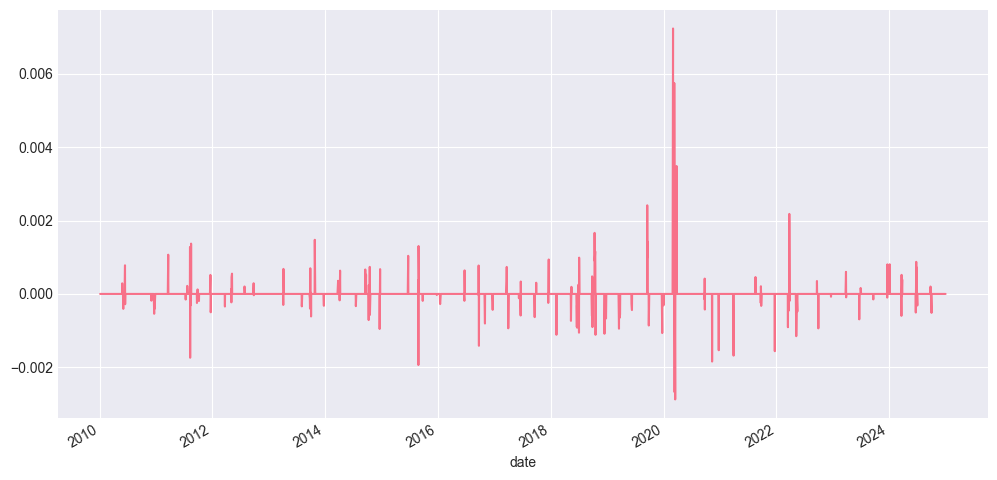

In [45]:
strategy_returns.plot()